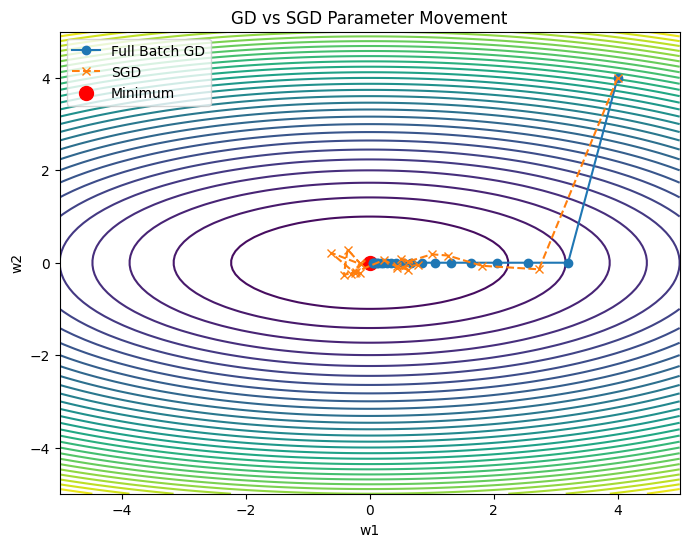

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Loss function
def loss(w):
    return w[0]**2 + 5*w[1]**2

# True gradient
def grad(w):
    return np.array([2*w[0], 10*w[1]])

# Simulated noisy gradient (for SGD)
def noisy_grad(w):
    noise = np.random.normal(0, 1, 2) * 2
    return grad(w) + noise


def run_descent(method="gd", lr=0.1, steps=20):

    w = np.array([4.0, 4.0])   # Starting point
    path = [w.copy()]

    for _ in range(steps):

        if method == "gd":
            g = grad(w)

        elif method == "sgd":
            g = noisy_grad(w)

        w = w - lr * g
        path.append(w.copy())

    return np.array(path)


# Run both
gd_path = run_descent("gd")
sgd_path = run_descent("sgd")

# Create contour plot
w1 = np.linspace(-5, 5, 100)
w2 = np.linspace(-5, 5, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 5*W2**2

plt.figure(figsize=(8,6))
plt.contour(W1, W2, Z, levels=30)

# Plot paths
plt.plot(gd_path[:,0], gd_path[:,1], 'o-', label="Full Batch GD")
plt.plot(sgd_path[:,0], sgd_path[:,1], 'x--', label="SGD")

plt.scatter(0,0, c='red', s=100, label="Minimum")
plt.xlabel("w1")
plt.ylabel("w2")
plt.legend()
plt.title("GD vs SGD Parameter Movement")
plt.show()